# Crop Yield Benchmark — survey paperThis notebook belongs to the survey paper[*Precision Agriculture: A Survey of Techniques*](../../../report/Precision_Agriculture_Survey_Paper.pdf),**not** to the deployed AgriTech system.It benchmarks six regressors on a public agricultural dataset in which yield isexpressed in quintals per acre. These results are reported as Table I of thepaper:| Model | MSE | R² ||---|---|---|| **K-Nearest Neighbours** | **0.4253** | **0.9104** || Gradient Boosting | 0.4461 | 0.9060 || Support Vector Regression | 0.4841 | 0.8980 || Linear Regression | 0.4874 | 0.8973 || Random Forest | 0.5599 | 0.8820 || ANN (MLP Regressor) | 0.6336 | 0.8665 |**The dataset is not included.** `crop yield data sheet.xlsx` is a third-partysample dataset cited in the paper; the cells below will not run without it.Outputs are preserved so the results remain readable.For the deployed system's yield model — different data, different target, and asignificant caveat — see [docs/models.md](../../../docs/models.md#yield-target).

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
ds = pd.read_excel('crop yield data sheet.xlsx')
ds

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0
...,...,...,...,...,...,...,...
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ds.dropna(inplace = True)
ds

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0
...,...,...,...,...,...,...,...
94,1250.0,77.0,28,78.0,23.0,20.0,9.0
95,425.0,60.0,39,65.0,19.0,17.0,6.5
96,1220.0,79.0,28,77.0,23.0,21.0,10.5
97,480.0,65.0,36,68.0,21.0,16.0,7.0


<Axes: >

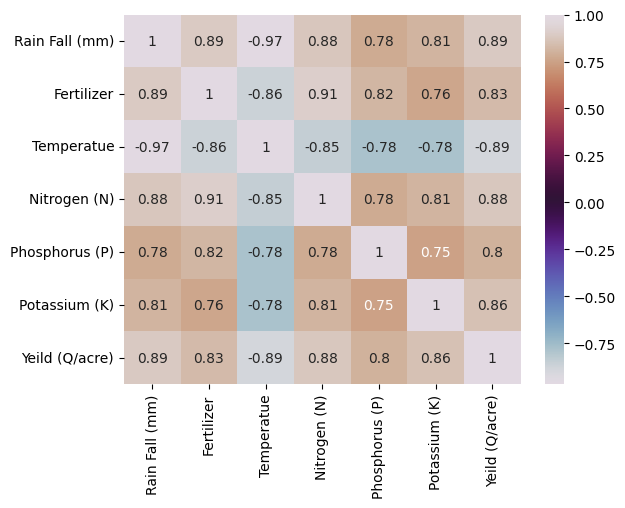

In [ ]:
corr = ds.corr()
sns.heatmap(corr, cmap = 'twilight', annot = True)

In [ ]:
from sklearn.model_selection import train_test_split

X = ds.drop(['Yeild (Q/acre)'], axis = 1)
y = ds['Yeild (Q/acre)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  0.48744083495680546
R2:  0.8972667287720567


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  0.49266604166666655
R2:  0.8961654616240267


In [ ]:

from sklearn.neural_network import MLPRegressor
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(100, 50, 25), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 0.6336267181771923
R-squared (R2): 0.8664565197917047


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  0.4725258718359742
R2:  0.900410213769129


In [ ]:
from sklearn.svm import SVR

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

y_pred = svr_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  0.48413669458700476
R2:  0.8979631110290254


In [ ]:

from sklearn.neighbors import KNeighborsRegressor

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)


knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 0.42533333333333356
R-squared (R2): 0.9103565365025467
